In [1]:
# Initialize Environment

!conda activate vesselfm
!nvidia-smi

Sun Dec 14 18:37:19 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    On  |   00000000:49:00.0 Off |                    0 |
| N/A   32C    P8             33W /  350W |       0MiB /  46068MiB |      0%   E. Process |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#!/usr/bin/env python

import os
import argparse
from pathlib import Path

import numpy as np
import nibabel as nib
from scipy.ndimage import zoom


def resample_to_spacing(data, src_spacing, tgt_spacing, order):
    """
    Data: np.ndarray with shape (X, Y, Z) or (X, Y, Z, C)
    src_spacing, tgt_spacing: iterable of length 3
    order: interpolation order (3 = cubic for image, 0 = nearest for label)
    """
    src_spacing = np.array(src_spacing, dtype=np.float32)
    tgt_spacing = np.array(tgt_spacing, dtype=np.float32)
    zoom_factors = src_spacing / tgt_spacing

    if data.ndim == 3:
        factors = zoom_factors
    elif data.ndim == 4:
        factors = (*zoom_factors, 1.0)  # don't scale channels
    else:
        raise ValueError(f"Unsupported data ndim {data.ndim}, expected 3 or 4.")

    resampled = zoom(data, factors, order=order)
    return resampled


def compute_label_bbox(label, margin=0):
    """
    Compute bounding box of non-zero labels, with margin in voxels.
    label: np.ndarray (X, Y, Z) integer labels
    returns: slices or None if no foreground
    """
    if np.max(label) == 0:
        return None

    coords = np.where(label > 0)
    xmin, xmax = coords[0].min(), coords[0].max()
    ymin, ymax = coords[1].min(), coords[1].max()
    zmin, zmax = coords[2].min(), coords[2].max()

    xmin = max(xmin - margin, 0)
    ymin = max(ymin - margin, 0)
    zmin = max(zmin - margin, 0)

    xmax = min(xmax + margin, label.shape[0] - 1)
    ymax = min(ymax + margin, label.shape[1] - 1)
    zmax = min(zmax + margin, label.shape[2] - 1)

    return (slice(xmin, xmax + 1),
            slice(ymin, ymax + 1),
            slice(zmin, zmax + 1))


def zscore_normalize(img, mask=None, eps=1e-8):
    """
    Z-score normalization with mask.
    img: np.ndarray float
    mask: boolean array or None
    """
    if mask is None:
        mask = np.ones_like(img, dtype=bool)
    vals = img[mask]
    if vals.size == 0:
        return img
    mean = vals.mean()
    std = vals.std()
    if std < eps:
        std = eps
    img = (img - mean) / std
    return img


def percentile_normalize(img, p_lo=0.5, p_hi=99.5, mask=None, eps=1e-8):
    """
    Map intensities between [p_lo, p_hi] percentiles to [0,1].
    Everything below p_lo goes to 0, above p_hi to 1.
    Usually mask = (img != 0) to ignore the air background.
    """
    if mask is None:
        mask = np.ones_like(img, dtype=bool)

    vals = img[mask]
    if vals.size == 0:
        return img

    lo = np.percentile(vals, p_lo)
    hi = np.percentile(vals, p_hi)

    if hi - lo < eps:
        # almost constant volume, nothing sensible to do
        return img

    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + eps)
    return img


def preprocess_pair(
    img_path,
    lbl_path,
    out_img_dir,
    out_lbl_dir,
    target_spacing,
    clip_range=None,
    do_zscore=False,
    crop_mode="label",
    crop_margin=10,
    percentile_norm=False,
    percentile_range=(0.5, 99.5),
):
    """
    Preprocess one image+label pair and save as .nii.gz.

    img_path, lbl_path: Path objects (input .nii/.nii.gz)
    out_img_dir, out_lbl_dir: Path objects (output directories)
    """
    print(f"Processing: {img_path.name}")

    img_nii = nib.load(str(img_path))
    img = img_nii.get_fdata().astype(np.float32)
    src_spacing = img_nii.header.get_zooms()[:3]

    # Labels
    if lbl_path is not None:
        lbl_nii = nib.load(str(lbl_path))
        lbl = lbl_nii.get_fdata().astype(np.int16)
    else:
        lbl_nii = None
        lbl = None

    # Resample image and label to target spacing
    if target_spacing is not None:
        img = resample_to_spacing(img, src_spacing, target_spacing, order=3)
        if lbl is not None:
            lbl = resample_to_spacing(lbl, src_spacing, target_spacing, order=0)
        spacing = target_spacing
    else:
        spacing = src_spacing

    # Intensity normalisation
    # HU clipping
    if clip_range is not None:
        lo, hi = clip_range
    else:
        lo, hi = -1000.0, 600.0  # default chest CT window

    img = np.clip(img, lo, hi)

    # Choose one of: percentile mapping, z-score, or simple [lo,hi] to [0,1]
    if percentile_norm:
        # Ignore pure-air voxels when computing percentiles
        mask = img != lo
        p_lo, p_hi = percentile_range
        img = percentile_normalize(img, p_lo=p_lo, p_hi=p_hi, mask=mask)
    elif do_zscore:
        mask = img != lo
        img = zscore_normalize(img, mask=mask)
    else:
        # Simple linear windowing [lo,hi] to [0,1]
        img = (img - lo) / (hi - lo + 1e-8)

    img = img.astype(np.float32)

    # Cropping

    # For inference, use crop_mode="none" so volume size stays global.
    if crop_mode == "label" and lbl is not None:
        bbox = compute_label_bbox(lbl, margin=crop_margin)
        if bbox is not None:
            img = img[bbox]
            lbl = lbl[bbox]
    elif crop_mode == "none":
        # No cropping
        pass
    elif crop_mode == "body":
        # Simple body mask
        mask = img != 0
        if np.any(mask):
            coords = np.where(mask)
            xmin, xmax = coords[0].min(), coords[0].max()
            ymin, ymax = coords[1].min(), coords[1].max()
            zmin, zmax = coords[2].min(), coords[2].max()
            xmin = max(xmin - crop_margin, 0)
            ymin = max(ymin - crop_margin, 0)
            zmin = max(zmin - crop_margin, 0)
            xmax = min(xmax + crop_margin, img.shape[0] - 1)
            ymax = min(ymax + crop_margin, img.shape[1] - 1)
            zmax = min(zmax + crop_margin, img.shape[2] - 1)
            bbox = (slice(xmin, xmax + 1),
                    slice(ymin, ymax + 1),
                    slice(zmin, zmax + 1))
            img = img[bbox]
            if lbl is not None:
                lbl = lbl[bbox]
    else:
        raise ValueError(f"Unknown crop_mode: {crop_mode}")

    affine = np.eye(4, dtype=np.float32)
    affine[0, 0] = spacing[0]
    affine[1, 1] = spacing[1]
    affine[2, 2] = spacing[2]

    out_img_dir.mkdir(parents=True, exist_ok=True)
    if out_lbl_dir is not None:
        out_lbl_dir.mkdir(parents=True, exist_ok=True)

    out_img_path = out_img_dir / img_path.name
    img_out = nib.Nifti1Image(img.astype(np.float32), affine)
    nib.save(img_out, str(out_img_path))

    if lbl is not None and out_lbl_dir is not None:
        out_lbl_path = out_lbl_dir / lbl_path.name
        lbl_out = nib.Nifti1Image(lbl.astype(np.int16), affine)
        nib.save(lbl_out, str(out_lbl_path))

    print(f"  -> saved image to {out_img_path}")
    if lbl is not None and out_lbl_dir is not None:
        print(f"  -> saved label to {out_lbl_path}")

def run_preprocess_av_ct_nii(
    images,
    labels=None,
    out_images=None,
    out_labels=None,
    target_spacing=(1.0, 1.0, 1.0),
    clip=None,                          # e.g. (-1000, 400)
    percentile_norm=False,
    percentile_range=(0.5, 99.5),
    zscore=False,
    crop_mode="label",
    crop_margin=10,
):
    """
    Notebook wrapper for preprocess_av_ct_nii. All paths are strings.
    """
    images_dir = Path(images)
    labels_dir = Path(labels) if labels is not None else None
    out_images_dir = Path(out_images) if out_images is not None else images_dir
    out_labels_dir = Path(out_labels) if out_labels is not None else labels_dir

    if labels_dir is None and crop_mode == "label":
        raise ValueError("crop_mode='label' requires labels directory.")

    img_files = sorted(
        [
            p for p in images_dir.iterdir()
            if p.is_file() and (p.name.endswith(".nii") or p.name.endswith(".nii.gz"))
        ]
    )

    if not img_files:
        raise RuntimeError(f"No NIfTI files found in {images_dir}")

    for img_path in img_files:
        img_name = img_path.name
        base = img_name
        if base.endswith(".nii.gz"):
            base = base[:-7]
        elif base.endswith(".nii"):
            base = base[:-4]

        lbl_path = None
        if labels_dir is not None:
            candidates = []
            candidates.append(labels_dir / (base + ".nii.gz"))
            candidates.append(labels_dir / (base + ".nii"))

            if base.startswith("image_"):
                idx = base[len("image_"):]
                candidates.append(labels_dir / f"label_{idx}.nii.gz")
                candidates.append(labels_dir / f"label_{idx}.nii")

            for cand in candidates:
                if cand.exists():
                    lbl_path = cand
                    break

            if lbl_path is None:
                raise FileNotFoundError(
                    f"Missing label for {img_path.name}. "
                    f"Tried: {[str(c) for c in candidates]}"
                )

        preprocess_pair(
            img_path=img_path,
            lbl_path=lbl_path,
            out_img_dir=out_images_dir,
            out_lbl_dir=out_labels_dir,
            target_spacing=target_spacing,
            clip_range=clip,
            do_zscore=zscore and not percentile_norm,
            crop_mode=crop_mode,
            crop_margin=crop_margin,
            percentile_norm=percentile_norm,
            percentile_range=percentile_range,
        )

In [3]:
run_preprocess_av_ct_nii(
    images="/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/data/imagesVal",
    labels="/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/data/labelsVal",
    out_images="/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/data/imagesVal_pre_3",
    out_labels="/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/data/labelsVal_pre_3",
    target_spacing=(1.0, 1.0, 1.0),
    clip=(-1000, 400),
    percentile_norm=True,
    percentile_range=(0.5, 99.5),
    zscore=False,
    crop_mode="none",
    crop_margin=0,
)

Processing: image_004.nii.gz
  -> saved image to /projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/data/imagesVal_pre_3/image_004.nii.gz
  -> saved label to /projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/data/labelsVal_pre_3/label_004.nii.gz
Processing: image_010.nii.gz
  -> saved image to /projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/data/imagesVal_pre_3/image_010.nii.gz
  -> saved label to /projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/data/labelsVal_pre_3/label_010.nii.gz
Processing: image_019.nii.gz
  -> saved image to /projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/data/imagesVal_pre_3/image_019.nii.gz
  -> saved label to /project

In [4]:
import logging

from monai import transforms
from monai.transforms import Compose

logger = logging.getLogger(__name__)


def generate_transforms(
    transforms_config: list[dict],
) -> list[transforms.Transform]:
    """
    Generate a list of transforms from a list of transform configurations.

    Args:
        transforms_config (list[dict]): List of transform configurations.

    Returns:
        list: List of transforms.
    """

    transform_list = []
    logger.debug(f"Generating {len(transforms_config)} transforms")

    for transform_config in transforms_config:
        transform_name = next(iter(transform_config))
        transform_kwargs = transform_config[transform_name]
        logger.debug(
            f"Generating transform {transform_name} with kwargs {transform_kwargs}"
        )
        transform: transforms.Transform = getattr(transforms, transform_name)(
            **transform_kwargs
        )  # type: ignore
        transform_list.append(transform)

    return Compose(transform_list)  # type: ignore

/projectnb/ec500kb/students/artmcl/.conda/envs/vesselfm/lib/python3.9/site-packages/monai/utils/module.py:399: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  pkg = __import__(module)  # top level module


In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from skimage.morphology import skeletonize, skeletonize_3d


# Soft skeletonization (for soft-clDice loss)

def _soft_erode(x: torch.Tensor) -> torch.Tensor:
    """
    x: (B, C, D, H, W) or (B, C, H, W)
    """
    if x.ndim == 4:  # 2D: B,C,H,W
        p1 = -F.max_pool2d(-x, kernel_size=(3, 1), stride=1, padding=(1, 0))
        p2 = -F.max_pool2d(-x, kernel_size=(1, 3), stride=1, padding=(0, 1))
        return torch.min(p1, p2)
    elif x.ndim == 5:  # 3D: B,C,D,H,W
        p1 = -F.max_pool3d(-x, kernel_size=(3, 1, 1), stride=1, padding=(1, 0, 0))
        p2 = -F.max_pool3d(-x, kernel_size=(1, 3, 1), stride=1, padding=(0, 1, 0))
        p3 = -F.max_pool3d(-x, kernel_size=(1, 1, 3), stride=1, padding=(0, 0, 1))
        return torch.min(torch.min(p1, p2), p3)
    else:
        raise ValueError(f"Expected 4D or 5D tensor, got shape {x.shape}")


def _soft_dilate(x: torch.Tensor) -> torch.Tensor:
    if x.ndim == 4:
        return F.max_pool2d(x, kernel_size=3, stride=1, padding=1)
    elif x.ndim == 5:
        return F.max_pool3d(x, kernel_size=3, stride=1, padding=1)
    else:
        raise ValueError(f"Expected 4D or 5D tensor, got shape {x.shape}")


def _soft_open(x: torch.Tensor) -> torch.Tensor:
    return _soft_dilate(_soft_erode(x))


def soft_skeleton(x: torch.Tensor, iters: int) -> torch.Tensor:
    """
    Differentiable soft skeletonization from the clDice paper (Shit et al., CVPR 2021).
    x: probability map in [0,1], shape (B,1,...) or (B,C,...)
    """
    img = x
    img1 = _soft_open(img)
    skel = F.relu(img - img1)

    for _ in range(iters):
        img = _soft_erode(img)
        img1 = _soft_open(img)
        delta = F.relu(img - img1)
        skel = skel + F.relu(delta - skel * delta)

    return skel


class SoftCLDiceLoss(nn.Module):
    """
    Soft clDice loss (1 - clDice) as in Shit et al. (CVPR 2021).
    You should usually call this on a SINGLE-CHANNEL vessel mask (e.g. A∪V vs BG).
    """

    def __init__(self, iter_: int = 3, smooth: float = 1.0):
        super().__init__()
        self.iters = iter_
        self.smooth = float(smooth)

    def forward(self, y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
        """
        y_true, y_pred: (B,1,D,H,W) or (B,1,H,W), values in [0,1]
        """
        if y_true.shape != y_pred.shape:
            raise ValueError(f"SoftCLDiceLoss: shape mismatch {y_true.shape} vs {y_pred.shape}")

        skel_pred = soft_skeleton(y_pred, self.iters)
        skel_true = soft_skeleton(y_true, self.iters)

        # Sum over spatial (and channel) dims
        dims = tuple(range(1, y_true.ndim))

        tprec = ( (skel_pred * y_true).sum(dim=dims) + self.smooth ) / (
                skel_pred.sum(dim=dims) + self.smooth
        )
        tsens = ( (skel_true * y_pred).sum(dim=dims) + self.smooth ) / (
                skel_true.sum(dim=dims) + self.smooth
        )

        cl_dice = 2.0 * tprec * tsens / (tprec + tsens + self.smooth)
        # Loss = 1 - clDice, averaged over batch
        return 1.0 - cl_dice.mean()


# Hard clDice metric (for eval/inference)

def hard_cldice(pred: np.ndarray, target: np.ndarray, eps: float = 1e-6) -> float:
    """
    Hard clDice metric using binary skeletonization.

    pred, target: boolean numpy arrays, shape (D,H,W) or (H,W)
    returns: scalar clDice in [0,1]
    """
    if pred.shape != target.shape:
        raise ValueError(f"hard_cldice: shape mismatch {pred.shape} vs {target.shape}")

    if pred.ndim == 3:
        skel_pred = skeletonize_3d(pred)
        skel_true = skeletonize_3d(target)
    elif pred.ndim == 2:
        skel_pred = skeletonize(pred)
        skel_true = skeletonize(target)
    else:
        raise ValueError(f"hard_cldice expects 2D or 3D arrays, got {pred.ndim}D")

    def _cl_score(v: np.ndarray, s: np.ndarray) -> float:
        denom = s.sum()
        if denom == 0:
            return 0.0
        return float((v & s).sum()) / float(denom)

    tprec = _cl_score(pred, skel_true)   # skeleton(gt) inside pred
    tsens = _cl_score(target, skel_pred) # skeleton(pred) inside gt

    if tprec + tsens < eps:
        return 0.0

    return float(2.0 * tprec * tsens / (tprec + tsens + eps))

In [6]:
from pathlib import Path

import numpy as np
import torch
from skimage.morphology import skeletonize, skeletonize_3d
from skimage.measure import euler_number, label
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score
import SimpleITK as sitk
from torch.utils.data import Dataset


class PretrainEvaluationDataset(Dataset):
    def __init__(self, data_path):
        data_dir = Path(data_path).resolve()
        self.val_data = {
            "deepvess": [
                torch.tensor(read_nifti(data_dir / "deepvess.nii"))[None],
                torch.tensor(read_nifti(data_dir / "deepvess_mask.nii"))[None],
            ],
            "deepvesselnet": [
                torch.tensor(read_nifti(data_dir / "deepvesselnet.nii"))[None],
                torch.tensor(read_nifti(data_dir / "deepvesselnet_mask.nii"))[None],
            ],
            "lightsheet": [
                torch.tensor(read_nifti(data_dir / "lightsheet.nii"))[None],
                torch.tensor(read_nifti(data_dir / "lightsheet_mask.nii"))[None],
            ],
            "minivess": [
                torch.tensor(read_nifti(data_dir / "minivess.nii"))[None],
                torch.tensor(read_nifti(data_dir / "minivess_mask.nii"))[None],
            ],
            "tubetk": [
                torch.tensor(read_nifti(data_dir / "tubetk.nii"))[None],
                torch.tensor(read_nifti(data_dir / "tubetk_mask.nii"))[None],
            ],
        }
        self._samples = list(self.val_data.keys())

    def __len__(self):
        return len(self._samples)

    def __getitem__(self, idx):
        name = self._samples[idx]
        image, mask = self.val_data[self._samples[idx]]
        return image, mask, name
        

class Evaluator:
    def extract_labels(self, gt_array, pred_array):
        """
        Adapted from https://github.com/CoWBenchmark/TopCoW_Eval_Metrics/blob/master/metric_functions.py#L18.
        """
        labels_gt = np.unique(gt_array)
        labels_pred = np.unique(pred_array)
        labels = list(set().union(labels_gt, labels_pred))
        labels = [int(x) for x in labels]
        return labels

    def betti_number_error(self, gt, pred):
        """
        Adapted from https://github.com/CoWBenchmark/TopCoW_Eval_Metrics/blob/master/metric_functions.py#L250.
        """
        labels = self.extract_labels(gt_array=gt, pred_array=pred)
        labels.remove(0)

        if len(labels) == 0:
            return 0, 0
        assert len(labels) == 1 and 1 in labels, "Invalid binary segmentatio.n"

        gt_betti_numbers = self.betti_number(gt)
        pred_betti_numbers = self.betti_number(pred)
        betti_0_error = abs(pred_betti_numbers[0] - gt_betti_numbers[0])
        betti_1_error = abs(pred_betti_numbers[1] - gt_betti_numbers[1])
        return betti_0_error, betti_1_error

    def betti_number(self, img):
        """
        Adapted from https://github.com/CoWBenchmark/TopCoW_Eval_Metrics/blob/master/metric_functions.py#L186.
        """
        assert img.ndim == 3
        N6 = 1
        N26 = 3

        padded = np.pad(img, pad_width=1)
        assert set(np.unique(padded)).issubset({0, 1})

        _, b0 = label(padded, return_num=True, connectivity=N26)
        euler_char_num = euler_number(padded, connectivity=N26)
        _, b2 = label(1 - padded, return_num=True, connectivity=N6)

        b2 -= 1
        b1 = b0 + b2 - euler_char_num
        return [b0, b1, b2]

    def cl_dice(self, v_p, v_l):
        """
        Adapted from https://github.com/jocpae/clDice/blob/master/cldice_metric/cldice.py.
        """
        def cl_score(v, s):
            return np.sum(v * s) / np.sum(s)

        if len(v_p.shape) == 2:
            tprec = cl_score(v_p, skeletonize(v_l))
            tsens = cl_score(v_l, skeletonize(v_p))
        elif len(v_p.shape) == 3:
            tprec = cl_score(v_p, skeletonize_3d(v_l))
            tsens = cl_score(v_l, skeletonize_3d(v_p))
        else:
            raise ValueError(f"Invalid shape for cl_dice: {v_p.shape}")
        return 2 * tprec * tsens / (tprec + tsens + np.finfo(float).eps)

    def estimate_metrics(self, pred_seg, gt_seg, threshold=0.5, fast=False):
        metrics = {}
        pred_seg_thresh = (pred_seg >= threshold).float().cpu()

        # estimate metrics
        tn, fp, fn, tp = confusion_matrix(
            gt_seg.flatten().cpu().clone().numpy(),
            pred_seg_thresh.flatten().cpu().clone().numpy(),
            labels=[0, 1],
        ).ravel()

        if fast:
            metrics["dice"] = (2 * tp) / (2 * tp + fp + fn)
            return metrics

        roc_auc = roc_auc_score(
            gt_seg.flatten().cpu().clone().detach().numpy(),
            pred_seg.flatten().cpu().clone().detach().numpy(),
        )

        pr_auc = average_precision_score(
            gt_seg.flatten().cpu().clone().detach().numpy(),
            pred_seg.flatten().cpu().clone().detach().numpy(),
        )

        cldice = self.cl_dice(
            pred_seg_thresh.squeeze().cpu().clone().detach().byte().numpy(),
            gt_seg.squeeze().cpu().clone().detach().byte().numpy(),
        )

        betti_0_error, betti_1_error = self.betti_number_error(
            gt_seg.squeeze().cpu().clone().detach().int().numpy(),
            pred_seg_thresh.squeeze().cpu().clone().detach().int().numpy(),
        )
        betti_0, betti_1, betti_2 = self.betti_number(
            pred_seg_thresh.squeeze().cpu().clone().detach().int().numpy()
        )

        metrics["recall_tpr_sensitivity"] = tp / (tp + fn)
        metrics["fpr"] = fp / (fp + tn)
        metrics["precision"] = tp / (tp + fp)
        metrics["specificity"] = tn / (tn + fp)
        metrics["jaccard_iou"] = tp / (tp + fp + fn)
        metrics["dice"] = (2 * tp) / (2 * tp + fp + fn)
        metrics["cldice"] = cldice
        metrics["accuracy"] = (tp + tn) / (tn + fp + tp + fn)
        metrics["roc_auc"] = roc_auc
        metrics["pr_auc_ap"] = pr_auc
        metrics["betti_0_error"] = betti_0_error
        metrics["betti_1_error"] = betti_1_error
        metrics["betti_0"] = betti_0
        metrics["betti_1"] = betti_1
        metrics["betti_2"] = betti_2
        return metrics


def read_nifti(path: str):
    return sitk.GetArrayFromImage(sitk.ReadImage(path))

def calculate_mean_metrics(results):
    """
    Compute mean over metrics.

    Accepts either:
      - dict: {case_id -> {metric_name -> value}}
      - list/tuple: [ {metric_name -> value}, ... ]
    Returns:
      dict: {metric_name -> mean_value}
    """
    import numpy as np

    # Handle dict input: {case_id: metrics_dict}
    if isinstance(results, dict):
        if not results:
            return {}
        results_list = list(results.values())
    else:
        # Assume it's an iterable of metrics dicts
        results_list = list(results)
        if not results_list:
            return {}

    mean_metrics = {}
    # Use keys from first case’s metrics
    for k in results_list[0].keys():
        vals = [float(r[k]) for r in results_list if k in r]
        if vals:
            mean_metrics[k] = float(np.mean(vals))

    return mean_metrics

In [7]:
"""Reader/writer classes; we follow https://github.com/MIC-DKFZ/nnUNet/tree/master/nnunetv2/imageio"""

import logging
import os
import json
from abc import ABC, abstractmethod
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
import SimpleITK as sitk

logger = logging.getLogger(__name__)


class BaseReaderWriter(ABC):
    supported_file_formats = []
    
    @staticmethod
    def _check_all_same(lst: List) -> bool:
        """
        Check if all elements in a list are the same
        Args:
            lst: List of elements
        Returns:
            Boolean indicating if all elements are the same
        """
        return all(x == lst[0] for x in lst)
    
    @abstractmethod
    def read_images(self, image_fnames: Union[List[str], Tuple[str, ...]]) -> Tuple[np.ndarray, dict]:
        """
        Read images from disk
        Args:
            image_fnames: List of image filenames
        Returns:
            Tuple of numpy array and dictionary
        """
        pass

    @abstractmethod
    def read_segs(self, seg_fnames: Union[List[str], Tuple[str, ...]]) -> Tuple[np.ndarray, dict]:
        """
        Read segmentations from disk
        Args:
            seg_fnames: List of segmentation filenames
        Returns:
            Tuple of numpy array and dictionary
        """
        pass

    @abstractmethod
    def write_seg(self, seg: np.ndarray, seg_fname: str, metadata: Optional[Dict[str, Any]] = None) -> None:
        """
        Write segmentation to disk
        Args:
            seg: Segmentation array
            seg_fname: Segmentation filename
            metadata: Metadata dictionary
        """
        pass


class NumpyReaderWriter(BaseReaderWriter):
    supported_file_formats = ["npy", "npz"]

    def __init__(self):
        super().__init__()

    def read_images(
        self, image_fnames: Union[str, list[str]], metdata_path: Optional[str] = None
    ) -> Tuple[np.ndarray, Dict[str, Any]]:
        """
        Read images from disk

        Args:
            image_fnames: List of image filenames
        Returns:
            Tuple of numpy array and dictionary
        """
        image_data = []
        if type(image_fnames) is str:
            image_fnames = [image_fnames]

        for image_fname in image_fnames:

            file_extension = os.path.basename(image_fname).split(".")[-1]
            if file_extension not in self.supported_file_formats:
                raise RuntimeError(f"File format not supported for {image_fname}")

            if file_extension == "npy":
                image_data.append(self._load_npy(image_fname))
                if image_data[-1].ndim != 3:
                    raise RuntimeError(
                        f"Image {image_fname} has dimension {image_data[-1].ndim}, expected 3"
                    )
            elif file_extension == "npz":
                new_images = self._load_npz(image_fname)
                for image in new_images:
                    if image.ndim != 3:
                        raise RuntimeError(
                            f"Image in {image_fname} has dimension {image.ndim}, expected 3"
                        )
                image_data.extend(new_images)

        if len(image_data) > 1:
            image_data = np.vstack(image_data)
        else:
            image_data = image_data[0]

        if metdata_path is not None:
            with open(metdata_path, "r") as f:
                metadata = json.load(f)
            spacing = metadata["spacing"]
            return image_data, {"spacing": spacing, "other": metadata}
        else:
            spacing = [1, 1, 1]
            return image_data, {"spacing": spacing}

    def _load_npy(self, fname: str) -> np.ndarray:
        return np.load(fname)

    def _load_npz(self, fname: str) -> list[np.ndarray]:
        file = np.load(fname)
        array = []
        for key in file.files:
            array.append(file[key])
        return array

    def read_segs(
        self, seg_fnames: Union[str, list[str]]
    ) -> Tuple[np.ndarray, Dict[str, Any]]:
        return self.read_images(seg_fnames)

    def write_seg(
        self,
        seg: np.ndarray,
        seg_fname: str,
        metadata: Optional[Dict[str, Any]] = None,
    ):
        file_extension = os.path.basename(seg_fname).split(".")[-1]
        if file_extension != ".npy":
            raise RuntimeError(
                f"File format {file_extension} not supported,  saving {seg_fname} failed!"
            )
        if metadata is not None:
            spacing = metadata["spacing"]
            with open(seg_fname, "wb") as f:
                np.save(f, seg)
            with open(seg_fname.replace(".npy", ".json"), "w") as f:
                json.dump(metadata, f)
        else:
            with open(seg_fname, "wb") as f:
                np.save(f, seg)


class NumpySeriesReaderWriter(BaseReaderWriter):
    supported_file_formats = ["npy_series", "npz_series"]
    slice_formats = ["npy", "npz"]

    def __init__(self):
        super().__init__()

    def read_images(
        self,
        image_folder: str,
        metdata_path: Optional[str] = None,
        start_idx: Optional[int] = None,
        end_idx: Optional[int] = None,
    ):
        """
        Read a series of images from disk given a the folder and optionally a start and end index.

        Args:
            image_folder: Folder containing the images
            start_idx: Start index of the images to read
            end_idx: End index of the images to read
        Returns:
            Tuple of numpy array and dictionary
        """
        image_files = os.listdir(image_folder)
        image_files = [
            f for f in image_files if f.endswith(".npy") or f.endswith(".npz")
        ]
        if start_idx is not None:
            image_files = [f for f in image_files if int(f.split(".")[0]) >= start_idx]
        if end_idx is not None:
            image_files = [f for f in image_files if int(f.split(".")[0]) < end_idx]
        image_files.sort()
        image_files = [os.path.join(image_folder, f) for f in image_files]
        image_data = []
        for image_fname in image_files:
            file_extension = os.path.basename(image_fname).split(".")[-1].lower()
            if file_extension not in self.slice_formats:
                raise RuntimeError(f"File format not supported for {image_fname}")
            if file_extension == "npy":
                image = self._load_npy(image_fname)
                image_data.append(image)
                if image_data[-1].ndim != 2:
                    raise RuntimeError(
                        f"Image {image_fname} has dimension {image_data[-1].ndim}, expected 2"
                    )
            elif file_extension == "npz":
                new_images = self._load_npz(image_fname)
                for image in new_images:
                    if image.ndim != 2:
                        raise RuntimeError(
                            f"Image in {image_fname} has dimension {image.ndim}, expected 2"
                        )
                image_data.extend(new_images)
        if metdata_path is not None:
            with open(metdata_path, "r") as f:
                metadata = json.load(f)
            return np.stack(image_data, axis=0), metadata
        else:
            spacing = [1, 1, 1]
            return np.stack(image_data, axis=0), {"spacing": spacing}

    def _load_npy(self, fname: str) -> np.ndarray:
        return np.load(fname)

    def _load_npz(self, fname: str) -> list[np.ndarray]:
        file = np.load(fname)
        array = []
        for key in file.files:
            array.append(file[key])
        return array

    def read_segs(
        self,
        seg_fnames: Union[str, list[str]],
        metadata: Optional[Dict[str, Any]] = None,
        start_idx: Optional[int] = None,
        end_idx: Optional[int] = None,
    ) -> Tuple[np.ndarray, Dict[str, Any]]:
        return self.read_images(seg_fnames, metadata, start_idx, end_idx)

    def _save_npy_series(self, array: np.ndarray, output_folder: str):
        os.makedirs(output_folder, exist_ok=True)
        for i in range(array.shape[0]):
            np.save(os.path.join(output_folder, f"{i}.npy"), array[i])

    def write_seg(
        self,
        seg: np.ndarray,
        seg_fname: str,
        metadata: Optional[Dict[str, Any]] = None,
    ):
        if metadata is not None:
            self._save_npy_series(seg, seg_fname)
            json.dump(metadata, os.path.join(seg_fname, "metadata.json"))
        else:
            self._save_npy_series(seg, seg_fname)


class SimpleITKReaderWriter(BaseReaderWriter):
    supported_file_formats = ["nii", "nii.gz", "mha", "mhd", "nrrd", "gz"]

    def __init__(self):
        super().__init__()

    def read_images(
        self, image_fnames: Union[str, list[str]]
    ) -> Tuple[np.ndarray, Dict[str, Any]]:
        """
        Read images from disk

        Args:
            image_fnames: List of image filenames
        Returns:
            Tuple of numpy array and dictionary
        """
        if type(image_fnames) is not list:
            image_fnames = [image_fnames]
        image_data = []
        image_metadata = {"spacing": [], "origin": [], "direction": []}
        for image_fname in image_fnames:

            if (
                os.path.basename(image_fname).split(".")[-1]
                not in self.supported_file_formats
            ):
                raise RuntimeError(f"File format not supported for {image_fname}")

            image = sitk.ReadImage(image_fname)
            logger.debug(f"Image {image_fname} has shape {image.GetSize()}")
            image_data.append(sitk.GetArrayFromImage(image))

            if image_data[-1].ndim != 3:
                raise RuntimeError(
                    f"Image {image_fname} has dimension {image_data[-1].ndim}, expected 3"
                )

            image_metadata["spacing"].append(image.GetSpacing())
            image_metadata["origin"].append(image.GetOrigin())
            image_metadata["direction"].append(image.GetDirection())

        if not self._check_all_same(image_metadata["spacing"]):
            logger.error("Spacing is not the same for all images")
            raise RuntimeError("Spacing is not the same for all images")
        if not self._check_all_same(image_metadata["origin"]):
            logger.warning("Origin is not the same for all images")
            logger.warning("Please check if this is expected behavior")
        if not self._check_all_same(image_metadata["direction"]):
            logger.warning("Direction is not the same for all images")
            logger.warning("Please check if this is expected behavior")

        sitk_metadata = {}
        for key in image_metadata.keys():
            sitk_metadata[key] = image_metadata[key][0]
        spacing = [
            sitk_metadata["spacing"][2],
            sitk_metadata["spacing"][0],
            sitk_metadata["spacing"][1],
        ]
        meta_data = {"spacing": spacing, "other": sitk_metadata}
        logger.debug(f"Spacing: {spacing}")
        logger.debug(f"Final shape: {np.vstack(image_data).shape}")
        return np.vstack(image_data), meta_data

    def read_segs(
        self, seg_fnames: Union[str, list[str]]
    ) -> Tuple[np.ndarray, Dict[str, Any]]:
        """
        Read segmentations from disk
        Args:
            seg_fnames: List of segmentation filenames
        Returns:
            Tuple of numpy array and dictionary
        """
        return self.read_images(seg_fnames)

    def write_seg(
        self,
        seg: np.ndarray,
        seg_fname: str,
        metadata: Optional[Dict[str, Any]] = None,
        compression: bool = True,
    ):
        """
        Write segmentation to disk
        Args:
            seg: Segmentation array
            seg_fname: Segmentation filename
            metadata: Metadata dictionary
        """
        seg = sitk.GetImageFromArray(seg)
        if metadata is not None:
            seg.SetSpacing(metadata["spacing"])
            seg.SetOrigin(metadata["origin"])
            seg.SetDirection(metadata["direction"])

        sitk.WriteImage(seg, seg_fname, compression)


def determine_reader_writer(file_ending: str):
    LIST_OF_READERS_WRITERS = [
        NumpyReaderWriter,
        SimpleITKReaderWriter,
        NumpySeriesReaderWriter,
    ]

    for reader_writer in LIST_OF_READERS_WRITERS:
        if file_ending.lower() in reader_writer.supported_file_formats:
            logger.debug(
                f"Automatically determined reader_writer: {reader_writer.__name__} for file ending: {file_ending}"
            )
            return reader_writer

    raise ValueError(f"No reader_writer found for file ending: {file_ending}")

In [8]:
""" Script to perform inference with vesselFM."""

import logging
import warnings
from pathlib import Path
import sys, os
from typing import Optional

repo_root = "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main"

if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import torch
import torch.nn as nn
import torch.nn.functional as F
import hydra
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra

import numpy as np
import json
import nibabel as nib
from tqdm import tqdm
from huggingface_hub import hf_hub_download
from monai.inferers import SlidingWindowInfererAdapt
from skimage.morphology import remove_small_objects
from skimage.exposure import equalize_hist
from scipy.ndimage import zoom as nd_zoom

from omegaconf import OmegaConf
from pathlib import Path


warnings.filterwarnings("ignore")
logger = logging.getLogger(__name__)

def build_model(num_classes=3, dropout=0.0):
    # Load inference config to get the same model definition with ckpt_path
    here = Path(__file__).resolve().parent
    config_dir = here / "configs"

    # Compose the full inference config
    GlobalHydra.instance().clear()
    with initialize_config_dir(config_dir=str(config_dir), job_name="av_model"):
        cfg_inf = compose(config_name="inference")

    if "model" not in cfg_inf:
        raise ValueError(
            f"'model' key not found in composed config. Top-level keys: {list(cfg_inf.keys())}"
        )

    mcfg = cfg_inf.model

    # Set number of output channels to num_classes
    if "out_channels" in mcfg:
        logger.info(f"[build_model] Setting model.out_channels -> {num_classes}")
        mcfg.out_channels = num_classes
    elif "num_classes" in mcfg:
        logger.info(f"[build_model] Setting model.num_classes -> {num_classes}")
        mcfg.num_classes = num_classes
    else:
        logger.warning(
            "[build_model] Neither 'out_channels' nor 'num_classes' found in model config; "
            "leaving output channels as-is."
        )

    # Dropout override
    if "dropout" in mcfg:
        logger.info(f"[build_model] Setting model.dropout -> {dropout}")
        mcfg.dropout = dropout

    # Instantiate MONAI DynUNet
    model = hydra.utils.instantiate(cfg_inf.model)

    # Load pretrained VesselFM weights
    try:
        logger.info(f"[build_model] Loading pretrained weights from {cfg_inf.ckpt_path}.")
        ckpt = torch.load(Path(cfg_inf.ckpt_path), map_location="cpu", weights_only=True)
    except Exception as e:
        logger.info(
            f"[build_model] Could not load ckpt from cfg_inf.ckpt_path ({e}). "
            "Falling back to Hugging Face vesselFM_base.pt."
        )
        hf_hub_download(repo_id="bwittmann/vesselFM", filename="meta.yaml")
        ckpt = torch.load(
            hf_hub_download(repo_id="bwittmann/vesselFM", filename="vesselFM_base.pt"),
            map_location="cpu",
            weights_only=True,
        )

    # Drop old head weights (1-channel) to avoid size mismatch
    head_keys = [k for k in ckpt.keys() if k.startswith("output_block.")]
    if head_keys:
        logger.info(
            f"[build_model] Removing {len(head_keys)} head params from checkpoint "
            f"to accommodate new 3-class head: {head_keys}"
        )
        for k in head_keys:
            ckpt.pop(k)

    # Now load backbone weights (strict=False allows missing head params)
    missing, unexpected = model.load_state_dict(ckpt, strict=False)
    logger.info(
        f"[build_model] Loaded pretrained VesselFM weights with "
        f"{len(missing)} missing and {len(unexpected)} unexpected keys "
        f"(expected when swapping to a 3-class head)."
    )

    # Add an explicit vessel head as a second physical head.
    if not hasattr(model, "vessel_head"):
        logger.info("[build_model] Adding 1x1x1 vessel_head on top of A/V logits.")
        model.vessel_head = nn.Conv3d(num_classes, 1, kernel_size=1)

    return model


def load_model(cfg, device):
    """
    Load the final A/V model (including Stage-3 av_refine_head) from ckpt_path.
    Assumes ckpt_path points to the av_ct_best_cldice.pt written by train_av.py.
    """
    # Load checkpoint
    try:
        logger.info(f"Loading model from {cfg.ckpt_path}.")
        ckpt = torch.load(Path(cfg.ckpt_path), map_location=device, weights_only=True)
    except Exception as e:
        logger.info(
            f"Could not load {cfg.ckpt_path} ({e}). "
            "Falling back to Hugging Face vesselFM_base.pt."
        )
        hf_hub_download(repo_id="bwittmann/vesselFM", filename="meta.yaml")
        ckpt = torch.load(
            hf_hub_download(repo_id="bwittmann/vesselFM", filename="vesselFM_base.pt"),
            map_location=device,
            weights_only=True,
        )

    # nstantiate the same backbone as in training
    model = hydra.utils.instantiate(cfg.model)

    # Figure out how many output channels the backbone has (should be 3)
    if "out_channels" in cfg.model:
        out_ch = cfg.model.out_channels
    elif "num_classes" in cfg.model:
        out_ch = cfg.model.num_classes
    else:
        out_ch = 3  # sensible default for your A/V/BG setup

    # Attach heads exactly like in train_av.py
    # Vessel head (not strictly needed for inference right now, but harmless)
    if not hasattr(model, "vessel_head"):
        logger.info("[load_model] Adding vessel_head for union-of-vessels output.")
        model.vessel_head = nn.Conv3d(out_ch, 1, kernel_size=1)

    # AV refine head: Stage-3 2-class A/V classifier on top of logits
    if not hasattr(model, "av_refine_head"):
        logger.info("[load_model] Adding av_refine_head (A/V refine) on top of logits.")
        model.av_refine_head = nn.Conv3d(out_ch, 2, kernel_size=1)

    # Load weights into this full architecture
    if isinstance(ckpt, dict):
        # Works for both raw state_dict and {'state_dict': ...}
        state = ckpt.get("state_dict", ckpt)
    else:
        state = ckpt

    missing, unexpected = model.load_state_dict(state, strict=False)
    logger.info(
        f"[load_model] Loaded checkpoint with {len(missing)} missing and "
        f"{len(unexpected)} unexpected keys."
    )

    return model


def get_paths(cfg):
    """
    Collect image and mask paths.

    Supports config layouts:
      - cfg.image_dir / cfg.mask_dir
      - cfg.image_path / cfg.mask_path
      - cfg.data.image_dir / cfg.data.mask_dir
      - cfg.data.image_path / cfg.data.mask_path

    Supports filename conventions:
      1) Same-name masks:
           image_004.nii.gz -> image_004.nii.gz
      2) image/label naming:
           image_004.nii.gz -> label_004.nii.gz
    """
    import os

    # Read directories from config with fallbacks
    image_dir_str = (
        OmegaConf.select(cfg, "data.image_dir")
        or OmegaConf.select(cfg, "image_dir")
        or OmegaConf.select(cfg, "data.image_path")
        or OmegaConf.select(cfg, "image_path")
    )

    mask_dir_str = (
        OmegaConf.select(cfg, "data.mask_dir")
        or OmegaConf.select(cfg, "mask_dir")
        or OmegaConf.select(cfg, "data.mask_path")
        or OmegaConf.select(cfg, "mask_path")
    )

    if image_dir_str is None:
        raise RuntimeError(
            "image directory not set in config "
            "(looked for 'image_dir', 'data.image_dir', "
            "'image_path', and 'data.image_path')."
        )

    image_dir = Path(image_dir_str)

    # Normalize mask_dir: either a Path or None
    if mask_dir_str is None or mask_dir_str in ("", "null"):
        mask_dir = None
    else:
        mask_dir = Path(mask_dir_str)

    # Collect images as Path objects
    # Use *.nii* so it works for .nii and .nii.gz
    image_paths = sorted(image_dir.glob("*.nii*"))
    if not image_paths:
        raise RuntimeError(f"No images found in {image_dir}")

    # If no mask_dir (pure inference), just return images
    if mask_dir is None:
        return image_paths, None

    # --- 3. Build mask paths with both naming schemes (also as Path objects) ---
    mask_paths = []

    for img_path in image_paths:
        # img_path is a Path
        img_name = img_path.name  # e.g. "image_004.nii.gz"

        # First try: mask has EXACT same basename as image
        same_name_mask = mask_dir / img_name
        if same_name_mask.exists():
            mask_paths.append(same_name_mask)
            continue

        # Second try: image_XXX.nii.gz -> label_XXX.nii.gz
        alt_mask = None
        if img_name.startswith("image_"):
            suffix = img_name[len("image_"):]          # "004.nii.gz"
            alt_mask = mask_dir / f"label_{suffix}"
            if alt_mask.exists():
                mask_paths.append(alt_mask)
                continue

        # No matching mask was found for this image
        msg = (
            f"Could not find a mask for image:\n  {img_path}\n"
            f"Tried:\n  {same_name_mask}"
        )
        if alt_mask is not None:
            msg += f"\n  {alt_mask}"
        raise FileNotFoundError(msg)

    return image_paths, mask_paths



def resample(image, factor=None, target_shape=None):
    if factor == 1:
        return image
    
    if target_shape:
        _, _, new_d, new_h, new_w = target_shape
    else:
        _, _, d, h, w = image.shape
        new_d, new_h, new_w = int(round(d / factor)), int(round(h / factor)), int(round(w / factor))
    return F.interpolate(image, size=(new_d, new_h, new_w), mode="trilinear", align_corners=False)


def resample_mask_to_spacing(mask, src_spacing, tgt_spacing, order=0):
    """
    Resample a 3D mask from src_spacing to tgt_spacing using nearest-neighbor (order=0).

    mask: (X, Y, Z) np.ndarray (integer labels)
    src_spacing, tgt_spacing: iterables of length 3 (sx, sy, sz)
    """
    src_spacing = np.array(src_spacing, dtype=np.float32)
    tgt_spacing = np.array(tgt_spacing, dtype=np.float32)
    zoom_factors = src_spacing / tgt_spacing  # Same convention as preprocess_av_ct_nii
    return nd_zoom(mask, zoom_factors, order=order)


def inference_core(cfg, raw_image_dir: Optional[str] = None):
    # seed libraries
    np.random.seed(cfg.seed)
    torch.manual_seed(cfg.seed)
    torch.cuda.manual_seed_all(cfg.seed)

    # set device
    logger.info(f"Using device {cfg.device}.")
    device = cfg.device

    # load model and ckpt
    model = load_model(cfg, device)
    model.to(device)
    model.eval()

    # init pre-processing transforms
    transforms = generate_transforms(cfg.transforms_config)

    # i/o
    output_folder = Path(cfg.output_folder)
    output_folder.mkdir(exist_ok=True)

    image_paths, mask_paths = get_paths(cfg)
    logger.info(f"Found {len(image_paths)} images in {cfg.image_path}.")

    if raw_image_dir is None:
        raw_image_dir = getattr(cfg, "raw_image_dir", None)

    raw_root = Path(raw_image_dir) if raw_image_dir is not None else None

    file_ending = (cfg.image_file_ending if cfg.image_file_ending else image_paths[0].suffix)
    image_reader_writer = determine_reader_writer(file_ending)()
    save_writer = determine_reader_writer(file_ending)()

    # init sliding window inferer
    logger.debug(f"Sliding window patch size: {cfg.patch_size}")
    logger.debug(f"Sliding window batch size: {cfg.batch_size}.")
    logger.debug(f"Sliding window overlap: {cfg.overlap}.")
    inferer = SlidingWindowInfererAdapt(
        roi_size=cfg.patch_size, sw_batch_size=cfg.batch_size, overlap=cfg.overlap, 
        mode=cfg.mode, sigma_scale=cfg.sigma_scale, padding_mode=cfg.padding_mode
    )

    # loop over images
    metrics_dict = {}
    with torch.no_grad():
        for idx, image_path in tqdm(
            enumerate(image_paths),
            total=len(image_paths),
            desc="Processing images.",
        ):
            preds = []  # per-scale logits (kept on device)
            mask_np = None

            for scale in cfg.tta.scales:
                # read image (and mask if available)
                image_np = image_reader_writer.read_images(image_path)[0].astype(np.float32)
                image = transforms(image_np)[None].to(device)  # (1,1,D,H,W) on device

                if mask_paths is not None and mask_np is None:
                    # Load 3-class GT: 0=bg,1=artery,2=vein, keep on CPU
                    mask_np = image_reader_writer.read_images(mask_paths[idx])[0].astype(np.int16)

                # TTA intensity transforms
                if cfg.tta.invert:
                    if image.mean() > cfg.tta.invert_mean_thresh:
                        image = 1 - image
                if cfg.tta.equalize_hist:
                    image_np = image.cpu().squeeze().numpy()
                    image_equal_hist_np = equalize_hist(image_np, nbins=cfg.tta.hist_bins)
                    image = torch.from_numpy(image_equal_hist_np).to(device)[None][None]

                # resample for scale, run model, resample back
                original_shape = image.shape
                image_scaled = resample(image, factor=scale)          # on device
                logits = inferer(image_scaled, model)                 # (1,3,D,H,W) on device
                logits = resample(logits, target_shape=original_shape)
                preds.append(logits.squeeze(0))                       # (3,D,H,W) on device

            # Preds is a list of per-scale logits, each (3,D,H,W) on device
            logits_ensemble = torch.stack(preds).mean(dim=0)          # (3,D,H,W) on device

            

            use_av_refine = getattr(cfg, "use_av_refine", False)
            
            if use_av_refine and hasattr(model, "av_refine_head"):
                # same refinement code as before
                base_probs = F.softmax(logits_ensemble.unsqueeze(0), dim=1)
                p_bg = base_probs[:, 0:1, ...]
                p_union = base_probs[:, 1:3, ...].sum(dim=1, keepdim=True).clamp(0.0, 1.0)
            
                av_logits = model.av_refine_head(logits_ensemble.unsqueeze(0))
                av_probs  = F.softmax(av_logits, dim=1)
                p_art_cond  = av_probs[:, 0:1, ...]
                p_vein_cond = av_probs[:, 1:2, ...]
            
                p_art  = p_union * p_art_cond
                p_vein = p_union * p_vein_cond
            
                denom = p_bg + p_art + p_vein + 1e-8
                probs_final = torch.cat([p_bg / denom, p_art / denom, p_vein / denom], dim=1)[0]
            else:
                # Use direct 3-class head (what you trained in Stage 1 & 2)
                if cfg.merging.max:
                    probs_final = torch.stack([F.softmax(p, dim=0) for p in preds]).max(dim=0)[0]
                else:
                    probs_final = torch.stack([F.softmax(p, dim=0) for p in preds]).mean(dim=0)

            # Move to CPU only when converting to numpy for saving / metrics
            label = probs_final.argmax(0).cpu().numpy().astype(np.uint8)

            # Class-wise CC cleanup
            if cfg.post.apply:
                cleaned = np.zeros_like(label, dtype=np.uint8)
                for c in (1, 2):  # artery, vein
                    cm = (label == c)
                    cm = remove_small_objects(
                        cm,
                        min_size=cfg.post.small_objects_min_size,
                        connectivity=cfg.post.small_objects_connectivity,
                    )
                    cleaned[cm] = c
                label = cleaned

            # Label is a numpy array (D, H, W) in model/reader order
            label_np = label.astype(np.uint8)

            # --- make sure we are aligned with the PREPROCESSED image first ---
            pre_nii = nib.load(str(image_path))
            pre_shape = pre_nii.shape

            # Fix simple orientation mismatch (axis 0 <-> 2) if needed
            if label_np.shape != pre_shape:
                if (
                    label_np.shape[0] == pre_shape[2]
                    and label_np.shape[1] == pre_shape[1]
                    and label_np.shape[2] == pre_shape[0]
                ):
                    # (D, H, W) -> (W, H, D) to match NIfTI (X, Y, Z)
                    label_np = np.transpose(label_np, (2, 1, 0))
                    logger.info(
                        f"Transposed prediction from {label.shape} to {label_np.shape} "
                        f"to match preprocessed image shape {pre_shape}."
                    )
                else:
                    raise RuntimeError(
                        f"Predicted mask shape {label_np.shape} does not match "
                        f"preprocessed image shape {pre_shape} and is not a simple 0<->2 swap."
                    )

            # Keep a copy in PREPROCESSED space for metrics
            label_pre = label_np.copy()

            # --- now optionally map prediction to RAW CT geometry ---
            ref_nii = pre_nii          # default: stay in preprocessed space
            label_save = label_pre     # default array to save

            if raw_root is not None:
                raw_path = raw_root / image_path.name
                if raw_path.is_file():
                    raw_nii = nib.load(str(raw_path))
                    raw_shape = raw_nii.shape

                    pre_spacing = pre_nii.header.get_zooms()[:3]
                    raw_spacing = raw_nii.header.get_zooms()[:3]

                    if (label_pre.shape != raw_shape) or (pre_spacing != raw_spacing):
                        logger.info(
                            f"Resampling prediction for {image_path.name} "
                            f"from preprocessed spacing {pre_spacing} "
                            f"to raw spacing {raw_spacing}."
                        )
                        # Use the same helper as preprocessing, but inverted
                        label_resampled = resample_to_spacing(
                            label_pre.astype(np.float32),
                            src_spacing=pre_spacing,
                            tgt_spacing=raw_spacing,
                            order=0,       # nearest-neighbor for labels
                        ).astype(np.uint8)

                        # Handle rounding differences in shape via center crop/pad
                        if label_resampled.shape != raw_shape:
                            logger.warning(
                                f"Resampled label shape {label_resampled.shape} != raw shape {raw_shape}; "
                                "cropping/padding to match."
                            )
                            out_arr = np.zeros(raw_shape, dtype=label_resampled.dtype)
                            min_shape = tuple(
                                min(a, b) for a, b in zip(label_resampled.shape, raw_shape)
                            )
                            src_slices = []
                            dst_slices = []
                            for a, b, m in zip(label_resampled.shape, raw_shape, min_shape):
                                src_start = (a - m) // 2
                                dst_start = (b - m) // 2
                                src_slices.append(slice(src_start, src_start + m))
                                dst_slices.append(slice(dst_start, dst_start + m))
                            out_arr[tuple(dst_slices)] = label_resampled[tuple(src_slices)]
                            label_resampled = out_arr

                        label_save = label_resampled
                        ref_nii = raw_nii
                    else:
                        # already same spacing/shape – just use raw affine
                        ref_nii = raw_nii
                        label_save = label_pre
                else:
                    logger.warning(
                        f"Raw image not found for {image_path.name} at {raw_path}; "
                        "saving prediction in preprocessed space instead."
                    )

            # --- build NIfTI in chosen reference space (raw if available) ---
            pred_nii = nib.Nifti1Image(
                label_save,
                affine=ref_nii.affine,
                header=ref_nii.header,
            )

            # Keep sform/qform consistent with reference image
            sform, sform_code = ref_nii.get_sform(coded=True)
            qform, qform_code = ref_nii.get_qform(coded=True)
            pred_nii.set_sform(sform, code=sform_code or 1)
            pred_nii.set_qform(qform, code=qform_code or 1)

            # Use reference image's filename stem for output
            if ref_nii.get_filename() is not None:
                base_name = Path(ref_nii.get_filename()).name.split(".")[0]
            else:
                base_name = image_path.name.split(".")[0]

            out_path = output_folder / f"{base_name}_{cfg.file_app}pred.nii.gz"
            nib.save(pred_nii, str(out_path))
            logger.info(f"Saved prediction to {out_path}")

            # Metrics if GT masks are available (in PREPROCESSED space)
            if mask_paths is not None and mask_np is not None:
                """
                label_pre: (D, H, W) prediction aligned to preprocessed image
                mask_np:   (D, H, W) GT as read by image_reader_writer
                """

                # Ensure GT mask has same shape/orientation as prediction
                gt = mask_np
                if gt.shape != label_pre.shape:
                    if (
                        gt.shape[0] == label_pre.shape[2]
                        and gt.shape[1] == label_pre.shape[1]
                        and gt.shape[2] == label_pre.shape[0]
                    ):
                        # simple 0<->2 swap
                        gt = np.transpose(gt, (2, 1, 0))
                        logger.info(
                            f"Transposed GT from {mask_np.shape} to {gt.shape} "
                            f"to match prediction shape {label_pre.shape}."
                        )
                    else:
                        raise RuntimeError(
                            f"GT mask shape {gt.shape} != prediction shape {label_pre.shape} "
                            f"and is not a simple 0<->2 swap."
                        )

                # -------------------------
                # UNION (A ∪ V) as binary
                # -------------------------
                union_pred = label_pre > 0    # (D,H,W) bool
                union_gt   = gt > 0           # (D,H,W) bool

                tp_u = np.logical_and(union_pred, union_gt).sum()
                fp_u = np.logical_and(union_pred, np.logical_not(union_gt)).sum()
                fn_u = np.logical_and(np.logical_not(union_pred), union_gt).sum()

                denom_u = union_pred.sum() + union_gt.sum()
                dice_union = 2.0 * tp_u / (denom_u + 1e-5) if denom_u > 0 else 0.0
                cldice_union = hard_cldice(union_pred.astype(bool), union_gt.astype(bool))

                pred_pos_u = tp_u + fp_u
                gt_pos_u   = tp_u + fn_u

                fp_pct_union_pred = 100.0 * fp_u / (pred_pos_u + 1e-5) if pred_pos_u > 0 else 0.0
                fn_pct_union_gt   = 100.0 * fn_u / (gt_pos_u + 1e-5)   if gt_pos_u > 0 else 0.0

                # -------------------------
                # ARTERY (class = 1)
                # -------------------------
                g_art = (gt == 1)
                if g_art.any():
                    p_art = (label_pre == 1)

                    tp_a = np.logical_and(p_art, g_art).sum()
                    fp_a = np.logical_and(p_art, np.logical_not(g_art)).sum()
                    fn_a = np.logical_and(np.logical_not(p_art), g_art).sum()

                    denom_a = p_art.sum() + g_art.sum()
                    dice_art = 2.0 * tp_a / (denom_a + 1e-5) if denom_a > 0 else 0.0
                    cldice_art = hard_cldice(p_art.astype(bool), g_art.astype(bool))

                    pred_pos_a = tp_a + fp_a
                    gt_pos_a   = tp_a + fn_a

                    fp_pct_art_pred = 100.0 * fp_a / (pred_pos_a + 1e-5) if pred_pos_a > 0 else 0.0
                    fn_pct_art_gt   = 100.0 * fn_a / (gt_pos_a + 1e-5)   if gt_pos_a > 0 else 0.0
                else:
                    dice_art = 0.0
                    cldice_art = 0.0
                    fp_pct_art_pred = 0.0
                    fn_pct_art_gt = 0.0

                # -------------------------
                # VEIN (class = 2)
                # -------------------------
                g_vein = (gt == 2)
                if g_vein.any():
                    p_vein = (label_pre == 2)

                    tp_v = np.logical_and(p_vein, g_vein).sum()
                    fp_v = np.logical_and(p_vein, np.logical_not(g_vein)).sum()
                    fn_v = np.logical_and(np.logical_not(p_vein), g_vein).sum()

                    denom_v = p_vein.sum() + g_vein.sum()
                    dice_vein = 2.0 * tp_v / (denom_v + 1e-5) if denom_v > 0 else 0.0
                    cldice_vein = hard_cldice(p_vein.astype(bool), g_vein.astype(bool))

                    pred_pos_v = tp_v + fp_v
                    gt_pos_v   = tp_v + fn_v

                    fp_pct_vein_pred = 100.0 * fp_v / (pred_pos_v + 1e-5) if pred_pos_v > 0 else 0.0
                    fn_pct_vein_gt   = 100.0 * fn_v / (gt_pos_v + 1e-5)   if gt_pos_v > 0 else 0.0
                else:
                    dice_vein = 0.0
                    cldice_vein = 0.0
                    fp_pct_vein_pred = 0.0
                    fn_pct_vein_gt = 0.0

                case_name = image_path.name.split(".")[0]

                logger.info(
                    f"{case_name}: "
                    f"Dice(A∪V)={dice_union:.4f} clDice(A∪V)={cldice_union:.4f} "
                    f"Dice(art)={dice_art:.4f} clDice(art)={cldice_art:.4f} "
                    f"Dice(vein)={dice_vein:.4f} clDice(vein)={cldice_vein:.4f} | "
                    f"FP%(A∪V|pred)={fp_pct_union_pred:.2f} FN%(A∪V|gt)={fn_pct_union_gt:.2f} | "
                    f"FP%(art|pred)={fp_pct_art_pred:.2f} FN%(art|gt)={fn_pct_art_gt:.2f} | "
                    f"FP%(vein|pred)={fp_pct_vein_pred:.2f} FN%(vein|gt)={fn_pct_vein_gt:.2f}"
                )

                metrics_dict[case_name] = {
                    "dice":               torch.tensor(dice_union),
                    "cldice":             torch.tensor(cldice_union),
                    "fp_pct_union_pred":  torch.tensor(fp_pct_union_pred),
                    "fn_pct_union_gt":    torch.tensor(fn_pct_union_gt),
                    "dice_art":           torch.tensor(dice_art),
                    "cldice_art":         torch.tensor(cldice_art),
                    "fp_pct_art_pred":    torch.tensor(fp_pct_art_pred),
                    "fn_pct_art_gt":      torch.tensor(fn_pct_art_gt),
                    "dice_vein":          torch.tensor(dice_vein),
                    "cldice_vein":        torch.tensor(cldice_vein),
                    "fp_pct_vein_pred":   torch.tensor(fp_pct_vein_pred),
                    "fn_pct_vein_gt":     torch.tensor(fn_pct_vein_gt),
                }

    # Summarize over all images
    if mask_paths is not None and len(metrics_dict) > 0:
        # Compute mean for every metric key we stored
        metric_names = list(next(iter(metrics_dict.values())).keys())
        mean_metrics = {}
        for m in metric_names:
            vals = [metrics_dict[k][m].item() for k in metrics_dict]
            mean_metrics[m] = float(np.mean(vals))

        logger.info(f"Mean Dice(A∪V): {mean_metrics['dice']:.4f}")
        logger.info(f"Mean clDice(A∪V): {mean_metrics['cldice']:.4f}")
        logger.info(f"Mean Dice(art): {mean_metrics['dice_art']:.4f}")
        logger.info(f"Mean clDice(art): {mean_metrics['cldice_art']:.4f}")
        logger.info(f"Mean Dice(vein): {mean_metrics['dice_vein']:.4f}")
        logger.info(f"Mean clDice(vein): {mean_metrics['cldice_vein']:.4f}")

        logger.info(f"Mean FP%(A∪V|pred): {mean_metrics['fp_pct_union_pred']:.2f}")
        logger.info(f"Mean FN%(A∪V|gt):   {mean_metrics['fn_pct_union_gt']:.2f}")
        logger.info(f"Mean FP%(art|pred): {mean_metrics['fp_pct_art_pred']:.2f}")
        logger.info(f"Mean FN%(art|gt):   {mean_metrics['fn_pct_art_gt']:.2f}")
        logger.info(f"Mean FP%(vein|pred): {mean_metrics['fp_pct_vein_pred']:.2f}")
        logger.info(f"Mean FN%(vein|gt):   {mean_metrics['fn_pct_vein_gt']:.2f}")

        with open(output_folder / "metrics_per_volume.json", "w") as f:
            json.dump(
                {k: {m: float(v[m].item()) for m in v} for k, v in metrics_dict.items()},
                f,
                indent=2,
            )

        with open(output_folder / "metrics_mean.json", "w") as f:
            json.dump(mean_metrics, f, indent=2)

from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra

def get_inference_cfg(
    repo_root,
    config_subdir="vesselfm/seg/configs",
    config_name="inference",
    overrides=None,
):
    """
    Compose the Hydra config for inference in a notebook-safe way.
    """
    if overrides is None:
        overrides = []

    config_dir = Path(repo_root) / config_subdir

    # Reset Hydra between calls in notebook
    GlobalHydra.instance().clear()
    with initialize_config_dir(config_dir=str(config_dir), job_name="nb_infer"):
        cfg = compose(config_name=config_name, overrides=overrides)

    return cfg

In [9]:
repo_root = "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main"

cfg = get_inference_cfg(
    repo_root=repo_root,
    overrides=[
        f"image_dir={repo_root}/data/imagesVal_pre_3",
        f"mask_dir={repo_root}/data/labelsVal_pre_3",
        f"output_folder={repo_root}/av_newmasks",
        f"raw_image_dir={repo_root}/data/imagesVal",
        "model.out_channels=3",
    ],
)

# Optionally inspect that the paths look as expected
print("image_dir:", cfg.image_dir)
print("mask_dir:", cfg.mask_dir)
print("output_folder:", cfg.output_folder)
print("raw_image_dir:", getattr(cfg, 'raw_image_dir', None))

# Run inference
inference_core(cfg)

image_dir: /projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/data/imagesVal_pre_3
mask_dir: /projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/data/labelsVal_pre_3
output_folder: /projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/av_newmasks
raw_image_dir: /projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/data/imagesVal


Processing images.: 100%|██████████| 35/35 [18:27<00:00, 31.64s/it]


In [10]:
from pathlib import Path
import json
import pandas as pd

pred_dir = Path("/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/av_newmasks")

mean_path = pred_dir / "metrics_mean.json"
per_vol_path = pred_dir / "metrics_per_volume.json"

# Mean metrics
if mean_path.exists():
    with open(mean_path, "r") as f:
        mean_metrics = json.load(f)
    print("Global mean metrics:")
    display(pd.Series(mean_metrics))
else:
    print("metrics_mean.json not found:", mean_path)

# Per-volume metrics
if per_vol_path.exists():
    with open(per_vol_path, "r") as f:
        per_volume_metrics = json.load(f)
    df_metrics = pd.DataFrame.from_dict(per_volume_metrics, orient="index")
    df_metrics.index.name = "case"
    print("Per-volume metrics:")
    display(df_metrics)
else:
    print("metrics_per_volume.json not found:", per_vol_path)


Global mean metrics:


dice                  0.427659
cldice                0.542391
fp_pct_union_pred    61.735191
fn_pct_union_gt      50.119474
dice_art              0.266310
cldice_art            0.382291
fp_pct_art_pred      71.442072
fn_pct_art_gt        74.599910
dice_vein             0.177349
cldice_vein           0.219640
fp_pct_vein_pred     85.480836
fn_pct_vein_gt       76.151298
dtype: float64

Per-volume metrics:


,dice,cldice,fp_pct_union_pred,fn_pct_union_gt,dice_art,cldice_art,fp_pct_art_pred,fn_pct_art_gt,dice_vein,cldice_vein,fp_pct_vein_pred,fn_pct_vein_gt
case,,,,,,,,,,,,
image_004,0.454410,0.563725,57.475143,51.213444,0.268068,0.354409,67.883125,76.996488,0.227191,0.280944,80.876315,72.020647
image_010,0.418824,0.572083,65.014042,47.834787,0.225341,0.320098,76.167815,78.629933,0.218108,0.246854,83.662000,67.203294
image_019,0.506833,0.666923,52.904639,45.136877,0.323817,0.460310,65.404851,69.565465,0.235710,0.268215,79.560403,72.164503
image_031,0.516588,0.641600,48.536231,48.144748,0.311797,0.447910,63.325252,72.883269,0.233362,0.280742,78.739556,74.138743
image_033,0.492421,0.651610,49.851692,51.631890,0.272286,0.454282,64.658390,77.855017,0.239814,0.278438,78.245224,73.284253
image_043,0.432437,0.508748,62.796089,48.375499,0.272239,0.363458,70.922723,74.407357,0.192534,0.248534,85.114400,72.751136
image_044,0.461284,0.550516,58.633954,47.869977,0.300564,0.424416,67.451456,72.081204,0.182923,0.235508,84.982303,76.606780
image_047,0.386754,0.531862,67.191957,52.901707,0.259214,0.397014,72.669984,75.349193,0.169370,0.234955,87.004757,75.688763
image_055,0.496875,0.602158,51.482031,49.085112,0.292769,0.427790,66.608118,73.935099,0.250453,0.285164,77.273231,72.109368


In [11]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# CTs
raw_img_dir = Path("/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/data/imagesVal")

# Predicted masks in raw space
pred_dir = Path("/projectnb/ec500kb/projects/Fall_2025_Projects/Project_4_VesselFM/VesselFMAdaptationMethod/av_newmasks")

# Case IDs, ex: image_001, image_002, ...
case_ids = sorted(p.name.split(".")[0] for p in raw_img_dir.glob("*.nii*"))
print("Found cases:", case_ids[:10], "...")


Found cases: ['image_004', 'image_010', 'image_019', 'image_031', 'image_033', 'image_043', 'image_044', 'image_047', 'image_055', 'image_064'] ...


In [12]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from nibabel.processing import resample_from_to

raw_root = Path(
    "/projectnb/ec500kb/projects/Fall_2025_Projects/"
    "Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/data/imagesVal"
)

pred_root = Path(
    "/projectnb/ec500kb/projects/Fall_2025_Projects/"
    "Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/av_newmasks"
)

gt_root = Path(
    "/projectnb/ec500kb/projects/Fall_2025_Projects/"
    "Project_4_VesselFM/VesselFMAdaptationMethod/vesselFM-main/vesselFM-main/data/labelsVal"
)


def _find_pred_path(case_id: str) -> Path:
    # Preferred: exact
    p = pred_root / f"{case_id}_pred.nii.gz"
    if p.exists():
        return p

    # Otherwise: anything that looks like a pred for this case
    cands = sorted(pred_root.glob(f"{case_id}*pred.nii*"))
    if not cands:
        raise FileNotFoundError(
            f"No prediction found for {case_id} in {pred_root}. "
            f"Tried {p.name} and glob {case_id}*pred.nii*"
        )
    return cands[0]


def _find_gt_path(case_id: str) -> Path:
    # Common conventions
    p_same = gt_root / f"{case_id}.nii.gz"
    if p_same.exists():
        return p_same

    if case_id.startswith("image_"):
        suffix = case_id[len("image_"):]  # e.g. "033"
        p_label = gt_root / f"label_{suffix}.nii.gz"
        if p_label.exists():
            return p_label

    # fallback: any nii that contains the case id or suffix
    cands = sorted(gt_root.glob(f"*{case_id}*.nii*"))
    if not cands and case_id.startswith("image_"):
        cands = sorted(gt_root.glob(f"*{suffix}*.nii*"))

    if not cands:
        raise FileNotFoundError(
            f"No GT found for {case_id} in {gt_root}. "
            f"Tried {p_same.name} and label_{suffix}.nii.gz (if applicable)."
        )
    return cands[0]


def _as_int_mask(nii: nib.Nifti1Image) -> nib.Nifti1Image:
    data = nii.get_fdata().astype(np.int16)
    return nib.Nifti1Image(data, nii.affine)


def _maybe_resample_mask_to_raw(mask_nii: nib.Nifti1Image, raw_nii: nib.Nifti1Image) -> nib.Nifti1Image:
    """
    If mask already matches raw grid (shape), keep it.
    Otherwise resample mask -> raw grid using world coordinates (nearest neighbor).
    """
    if mask_nii.shape == raw_nii.shape:
        return mask_nii
    return resample_from_to(mask_nii, raw_nii, order=0)


def _extract_slice(vol3d: np.ndarray, axis: str, index: int):
    """
    Returns a 2D slice with a transpose so it displays in a typical orientation.
    """
    if axis == "sagittal":
        sl = vol3d[index, :, :].T
    elif axis == "coronal":
        sl = vol3d[:, index, :].T
    elif axis == "axial":
        sl = vol3d[:, :, index].T
    else:
        raise ValueError("axis must be 'axial', 'sagittal', or 'coronal'")
    return sl


def _overlay_rgb(img_slice: np.ndarray, mask_slice: np.ndarray, alpha: float):
    # Window + normalize for display (CT-like)
    img_w = np.clip(img_slice, -1000, 400)
    img_w = (img_w - img_w.min()) / (img_w.max() - img_w.min() + 1e-8)

    art = (mask_slice == 1)
    vein = (mask_slice == 2)

    rgb = np.stack([img_w, img_w, img_w], axis=-1)

    # artery (red)
    rgb[art, 0] = 1.0
    rgb[art, 1] *= (1 - alpha)
    rgb[art, 2] *= (1 - alpha)

    # vein (blue)
    rgb[vein, 2] = 1.0
    rgb[vein, 0] *= (1 - alpha)
    rgb[vein, 1] *= (1 - alpha)

    return rgb


def show_raw_pred_and_gt(case_id: str, axis="axial", index=None, alpha=0.45, side_by_side=True):
    """
    Displays:
      - raw CT with predicted A/V mask overlay
      - raw CT with GT A/V mask overlay
    Both overlays are forced onto the raw CT grid first.
    """
    raw_path = raw_root / f"{case_id}.nii.gz"
    pred_path = _find_pred_path(case_id)
    gt_path = _find_gt_path(case_id)

    raw_nii = nib.load(str(raw_path))
    pred_nii = _as_int_mask(nib.load(str(pred_path)))
    gt_nii = _as_int_mask(nib.load(str(gt_path)))

    # Resample masks onto raw grid if needed
    pred_on_raw = _maybe_resample_mask_to_raw(pred_nii, raw_nii)
    gt_on_raw = _maybe_resample_mask_to_raw(gt_nii, raw_nii)

    # Canonicalize for nicer slicing/display consistency
    raw_can = nib.as_closest_canonical(raw_nii)
    pred_can = nib.as_closest_canonical(pred_on_raw)
    gt_can = nib.as_closest_canonical(gt_on_raw)

    img = raw_can.get_fdata().astype(np.float32)
    pred = pred_can.get_fdata().astype(np.int16)
    gt = gt_can.get_fdata().astype(np.int16)

    if img.shape != pred.shape or img.shape != gt.shape:
        raise ValueError(
            f"Post-resample mismatch: img {img.shape}, pred {pred.shape}, gt {gt.shape}"
        )

    # Choose index
    if axis == "sagittal":
        axis_len = img.shape[0]
    elif axis == "coronal":
        axis_len = img.shape[1]
    else:
        axis_len = img.shape[2]

    if index is None:
        index = axis_len // 2

    img_slice = _extract_slice(img, axis, index)
    pred_slice = _extract_slice(pred, axis, index)
    gt_slice = _extract_slice(gt, axis, index)

    rgb_pred = _overlay_rgb(img_slice, pred_slice, alpha)
    rgb_gt = _overlay_rgb(img_slice, gt_slice, alpha)

    # Figure sizing based on aspect ratio
    h, w, _ = rgb_pred.shape
    base_w = 8
    base_h = base_w * (h / w)

    if side_by_side:
        fig, axes = plt.subplots(1, 2, figsize=(2 * base_w, base_h))
        axes[0].imshow(rgb_pred, origin="lower", aspect="equal")
        axes[0].axis("off")
        axes[0].set_title(f"{case_id} – {axis} {index} (Pred)")

        axes[1].imshow(rgb_gt, origin="lower", aspect="equal")
        axes[1].axis("off")
        axes[1].set_title(f"{case_id} – {axis} {index} (GT)")

        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(base_w, base_h))
        plt.imshow(rgb_pred, origin="lower", aspect="equal")
        plt.axis("off")
        plt.title(f"{case_id} – {axis} {index} (Pred)")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(base_w, base_h))
        plt.imshow(rgb_gt, origin="lower", aspect="equal")
        plt.axis("off")
        plt.title(f"{case_id} – {axis} {index} (GT)")
        plt.tight_layout()
        plt.show()

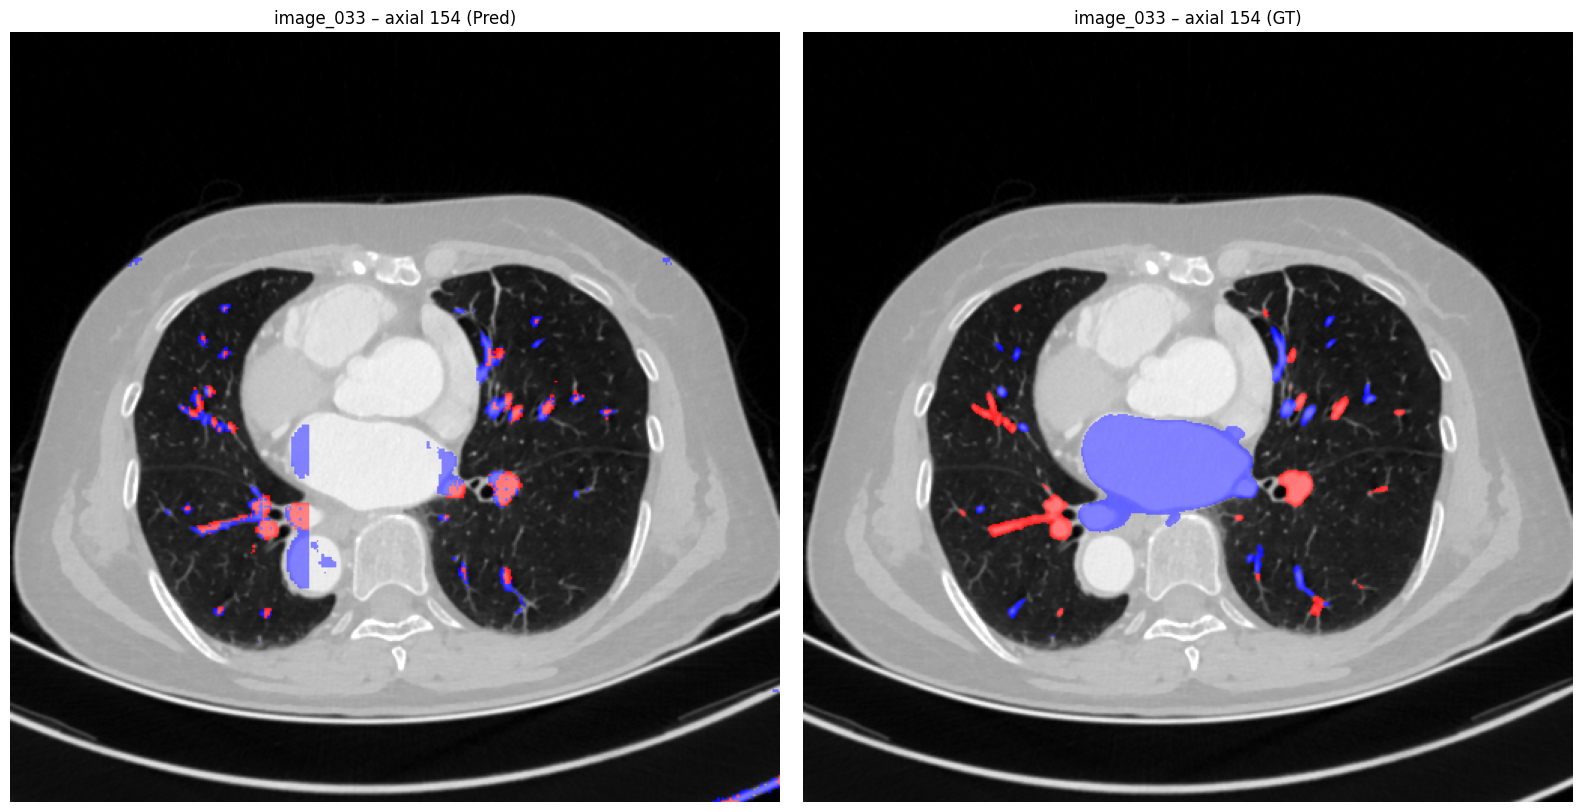

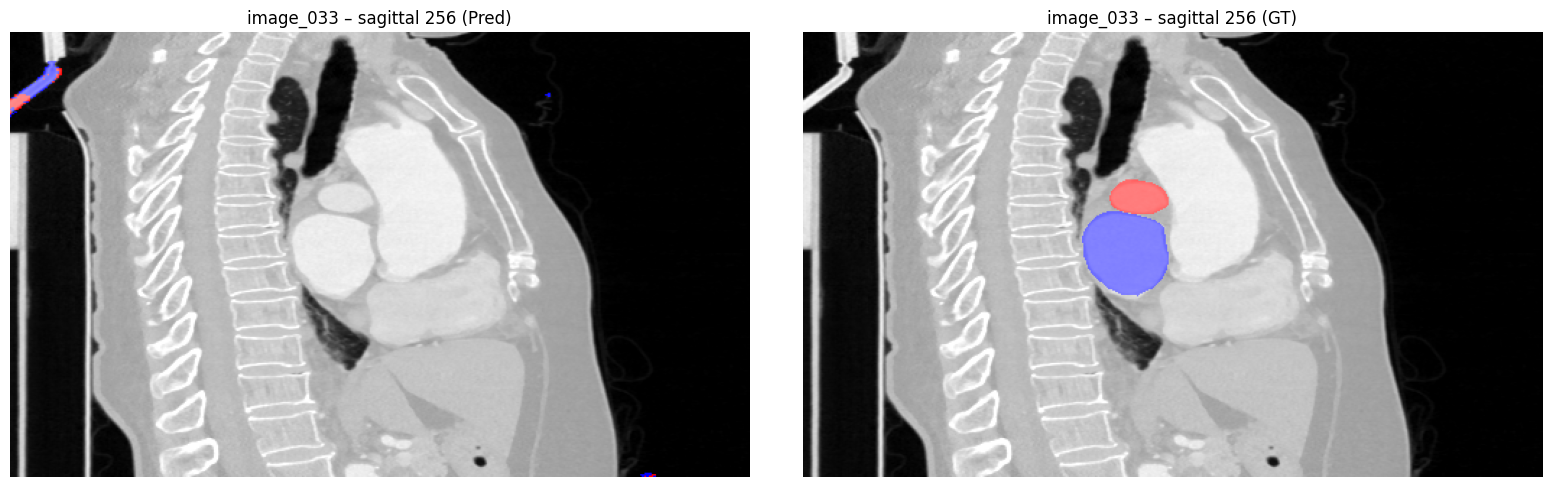

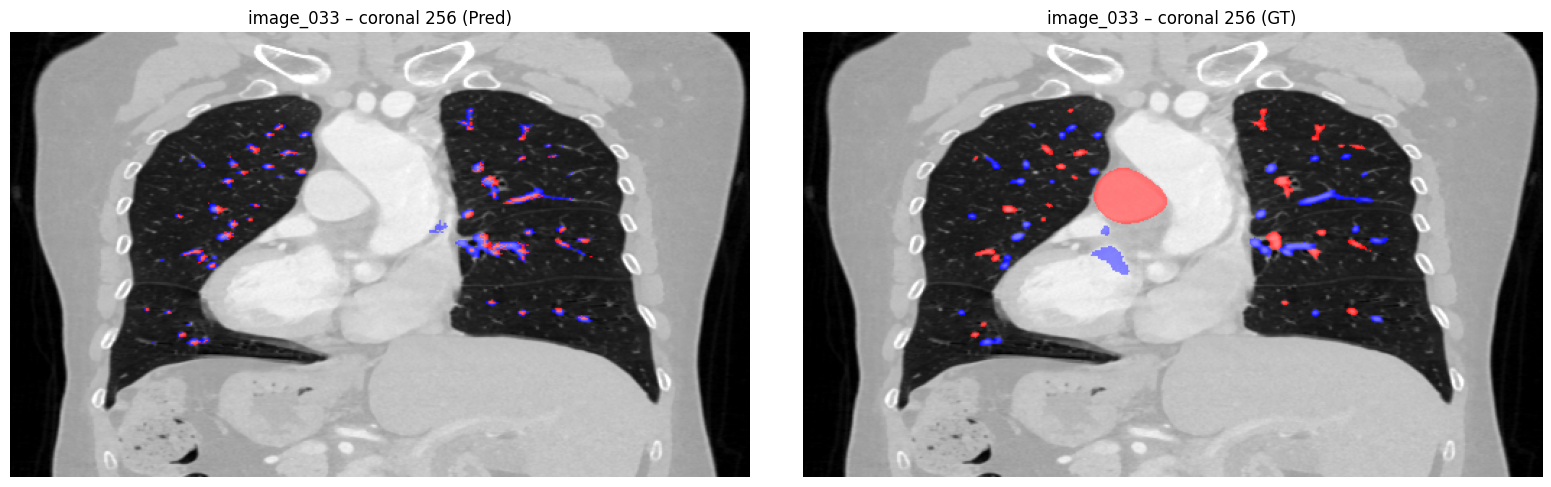

In [13]:
example_case = "image_033"
show_raw_pred_and_gt(example_case, axis="axial")
show_raw_pred_and_gt(example_case, axis="sagittal")
show_raw_pred_and_gt(example_case, axis="coronal")